# LightGBM Model Eğitimi ve Değerlendirme

Bu notebook'ta kısa vadeli elektrik talebi tahmini için aşağıdaki adımlar uygulanacaktır:
1. Veri yükleme ve hazırlık
2. Kronolojik train/test split
3. Naive baseline model
4. LightGBM modeli eğitimi
5. Walk-forward validation
6. Karşılaştırma grafikleri
7. Model kaydetme

## 0. Kütüphaneler ve Ayarlar

Gerekli Python kütüphaneleri içe aktarılıyor. `lightgbm` model eğitimi, `sklearn` metrik hesaplamaları, `matplotlib` ve `seaborn` görselleştirme için kullanılmaktadır.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import lightgbm as lgb
import pickle
import warnings
import os

from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

SEED = 42
np.random.seed(SEED)

os.makedirs('../models', exist_ok=True)
os.makedirs('../outputs/figures', exist_ok=True)

print('Kütüphaneler başarıyla yüklendi.')
print(f'LightGBM versiyon: {lgb.__version__}')

Kütüphaneler başarıyla yüklendi.
LightGBM versiyon: 4.6.0


## 1. Veri Yükleme ve Hazırlık

Feature engineering aşamasında oluşturulmuş `featured_data.csv` dosyası yükleniyor. 
- **Hedef değişken:** `consumption_MWh` (saatlik tüketim, MWh)
- **Feature listesi:** `datetime` ve `consumption_MWh` dışındaki tüm sütunlar

Lag özelliklerindeki NaN satırları (ilk 336 satır) kaldırılıyor.

In [2]:
df = pd.read_csv('../data/processed/featured_data.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

# Hedef ve feature sütunları
TARGET = 'consumption_MWh'
EXCLUDE = ['datetime', TARGET]
FEATURES = [c for c in df.columns if c not in EXCLUDE]

# Lag'lardan kaynaklanan NaN satırlarını kaldır
df = df.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)

print(f'Veri boyutu       : {df.shape}')
print(f'Tarih aralığı     : {df["datetime"].min()} → {df["datetime"].max()}')
print(f'Hedef değişken    : {TARGET}')
print(f'Feature sayısı    : {len(FEATURES)}')
print(f'\nFeature listesi:')
for f in FEATURES:
    print(f'  • {f}')

Veri boyutu       : (52248, 43)


Tarih aralığı     : 2018-01-15 00:00:00 → 2023-12-31 23:00:00
Hedef değişken    : consumption_MWh
Feature sayısı    : 41

Feature listesi:
  • lag_24
  • lag_48
  • lag_168
  • lag_336
  • rolling_mean_24
  • rolling_std_24
  • rolling_mean_168
  • rolling_max_72
  • hour
  • day_of_week
  • month
  • day_of_year
  • year
  • is_weekend
  • is_holiday
  • hour_sin
  • hour_cos
  • month_sin
  • month_cos
  • day_of_week_sin
  • day_of_week_cos
  • total_generation_MWh
  • natural_gas
  • hydro_dam
  • lignite
  • hydro_river
  • coal_imported
  • wind
  • solar
  • fuel_oil
  • geothermal
  • asphaltite_coal
  • hard_coal
  • biomass
  • naphtha
  • LNG
  • international
  • waste_heat
  • TRY/MWh
  • USD/MWh
  • EUR/MWh


## 2. Train / Test Split (Kronolojik)

Zaman serisi verisinde **veri sızıntısını önlemek** için kronolojik sırada bölme yapılmaktadır.
- İlk **%80** → **train seti** (model eğitimi)
- Son **%20** → **test seti** (nihai değerlendirme)

> `shuffle=False` — tarih sırası bozulmaz.

In [3]:
split_idx = int(len(df) * 0.80)

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]

print(f'Train seti : {train_df["datetime"].min().date()} → {train_df["datetime"].max().date()}  ({len(train_df):,} satır)')
print(f'Test seti  : {test_df["datetime"].min().date()} → {test_df["datetime"].max().date()}  ({len(test_df):,} satır)')
print(f'\nTrain/Test oranı: {len(train_df)/len(df)*100:.1f}% / {len(test_df)/len(df)*100:.1f}%')

Train seti : 2018-01-15 → 2022-10-22  (41,798 satır)
Test seti  : 2022-10-22 → 2023-12-31  (10,450 satır)

Train/Test oranı: 80.0% / 20.0%


## 3. Yardımcı Metrik Fonksiyonu

Model performansını ölçmek için üç metrik kullanılmaktadır:
- **MAPE** (Mean Absolute Percentage Error): Yüzde hata, yorumlanması kolaydır.
- **MAE** (Mean Absolute Error): Ortalama mutlak hata, MWh cinsinden.
- **RMSE** (Root Mean Squared Error): Büyük hatalara daha duyarlı.

In [4]:
def compute_metrics(y_true, y_pred, label=''):
    """MAPE, MAE ve RMSE hesaplar ve yazdırır."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    if label:
        print(f'[{label}]')
    print(f'  MAPE : {mape:.3f}%')
    print(f'  MAE  : {mae:,.1f} MWh')
    print(f'  RMSE : {rmse:,.1f} MWh')
    return {'MAPE': mape, 'MAE': mae, 'RMSE': rmse}

print('Metrik fonksiyonu hazır.')

Metrik fonksiyonu hazır.


## 4. Naive Baseline Model

**Naive (Saf) Baseline:** Tahmin olarak 168 saat (7 gün) önceki tüketim değeri kullanılır.

$$\hat{y}_t = y_{t-168}$$

Bu yaklaşım, elektrik tüketiminin haftalık sezonselliğini varsayar ve herhangi bir makine öğrenmesi modeli için **minimum performans çıtası** işlevi görür.

In [5]:
# lag_168 zaten feature olarak mevcut → doğrudan kullan
naive_pred = test_df['lag_168'].values
naive_true = y_test.values

print('=' * 40)
print('NAİVE BASELINE (lag_168) — TEST SETİ')
print('=' * 40)
metrics_naive = compute_metrics(naive_true, naive_pred, label='Naive Baseline')

NAİVE BASELINE (lag_168) — TEST SETİ
[Naive Baseline]
  MAPE : 4.277%
  MAE  : 1,533.5 MWh
  RMSE : 2,696.3 MWh


## 5. LightGBM Modeli

**LightGBM** (Light Gradient Boosting Machine), gradient boosting algoritmasının hızlandırılmış bir versiyonudur. Büyük veri setlerinde ve zaman serisi tahmininde yaygın olarak tercih edilir.

**Early stopping** için train setinin son **%10**'u validation seti olarak ayrılmıştır. Bu sayede model aşırı öğrenmeden (overfitting) önce durur.

In [6]:
# Train'in son %10'u validation için
val_split = int(len(X_train) * 0.90)
X_tr, X_val = X_train.iloc[:val_split], X_train.iloc[val_split:]
y_tr, y_val = y_train.iloc[:val_split], y_train.iloc[val_split:]

print(f'Eğitim alt seti  : {len(X_tr):,} satır')
print(f'Validation seti  : {len(X_val):,} satır')
print(f'Test seti        : {len(X_test):,} satır')

# Model parametreleri
lgbm_params = dict(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    min_child_samples=20,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

model = lgb.LGBMRegressor(**lgbm_params)

model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

print(f'\nEn iyi iterasyon : {model.best_iteration_}')

Eğitim alt seti  : 37,618 satır
Validation seti  : 4,180 satır
Test seti        : 10,450 satır


[100]	valid_0's l2: 353777
[200]	valid_0's l2: 289780


[300]	valid_0's l2: 277109
[400]	valid_0's l2: 272508


[500]	valid_0's l2: 266460
[600]	valid_0's l2: 262569


[700]	valid_0's l2: 262690

En iyi iterasyon : 687


In [7]:
lgbm_pred = model.predict(X_test)

print('=' * 40)
print('LightGBM — TEST SETİ')
print('=' * 40)
metrics_lgbm = compute_metrics(y_test.values, lgbm_pred, label='LightGBM')

LightGBM — TEST SETİ
[LightGBM]
  MAPE : 1.198%
  MAE  : 454.2 MWh
  RMSE : 741.5 MWh


## 6. Walk-Forward Validation (Genişleyen Pencere)

**Walk-forward validation**, zaman serisi modellerinin gerçekçi değerlendirilmesi için kullanılır.

- **6 fold**, **genişleyen pencere** (expanding window)
- Her fold: **4 aylık test penceresi** (~2928 saat)
- Her foldda model, önceki tüm verilerle eğitilir; sonraki 4 ay tahmin edilir

Bu yaklaşım, modelin zamanla nasıl davrandığını ve istikrarlı olup olmadığını gösterir.

In [8]:
N_FOLDS = 6
TEST_WINDOW_HOURS = 4 * 30 * 24  # ~4 ay

# Tüm veriyi kullan (train + test)
X_all = df[FEATURES]
y_all = df[TARGET]
dates_all = df['datetime']

# Her fold için başlangıç noktasını hesapla
total = len(df)
# En az 1 yıllık (8760 saat) eğitim verisi gereksinimi
min_train = 8760
available = total - min_train
fold_step = available // N_FOLDS

wfv_results = []

print(f'Walk-Forward Validation — {N_FOLDS} Fold, {TEST_WINDOW_HOURS // 24 // 30} Aylık Test Penceresi')
print('=' * 70)

for fold in range(N_FOLDS):
    # Expanding window: her fold bir adım ilerler
    train_end   = min_train + fold * fold_step
    test_start  = train_end
    test_end    = min(test_start + TEST_WINDOW_HOURS, total)

    if test_start >= total:
        break

    X_tr_f = X_all.iloc[:train_end]
    y_tr_f = y_all.iloc[:train_end]
    X_te_f = X_all.iloc[test_start:test_end]
    y_te_f = y_all.iloc[test_start:test_end]

    # Val split (%10)
    v_split = int(len(X_tr_f) * 0.90)
    m = lgb.LGBMRegressor(**lgbm_params)
    m.fit(
        X_tr_f.iloc[:v_split], y_tr_f.iloc[:v_split],
        eval_set=[(X_tr_f.iloc[v_split:], y_tr_f.iloc[v_split:])],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )

    preds = m.predict(X_te_f)
    y_te_arr = y_te_f.values
    mask = y_te_arr != 0
    mape = np.mean(np.abs((y_te_arr[mask] - preds[mask]) / y_te_arr[mask])) * 100
    mae  = mean_absolute_error(y_te_arr, preds)
    rmse = np.sqrt(mean_squared_error(y_te_arr, preds))

    wfv_results.append({'Fold': fold + 1, 'MAPE': mape, 'MAE': mae, 'RMSE': rmse,
                        'train_end': dates_all.iloc[train_end - 1].date(),
                        'test_start': dates_all.iloc[test_start].date(),
                        'test_end': dates_all.iloc[test_end - 1].date()})

    print(f'Fold {fold+1} | Eğitim: → {dates_all.iloc[train_end-1].date()} '
          f'| Test: {dates_all.iloc[test_start].date()} → {dates_all.iloc[test_end-1].date()} '
          f'| MAPE: {mape:.3f}% | MAE: {mae:,.0f} | RMSE: {rmse:,.0f}')

wfv_df = pd.DataFrame(wfv_results)

print('=' * 70)
print(f'Ortalama MAPE : {wfv_df["MAPE"].mean():.3f}% ± {wfv_df["MAPE"].std():.3f}%')
print(f'Ortalama MAE  : {wfv_df["MAE"].mean():,.1f} ± {wfv_df["MAE"].std():,.1f} MWh')
print(f'Ortalama RMSE : {wfv_df["RMSE"].mean():,.1f} ± {wfv_df["RMSE"].std():,.1f} MWh')

Walk-Forward Validation — 6 Fold, 4 Aylık Test Penceresi


Fold 1 | Eğitim: → 2019-01-14 | Test: 2019-01-15 → 2019-05-14 | MAPE: 0.475% | MAE: 155 | RMSE: 203


Fold 2 | Eğitim: → 2019-11-12 | Test: 2019-11-13 → 2020-03-11 | MAPE: 0.501% | MAE: 177 | RMSE: 295


Fold 3 | Eğitim: → 2020-09-09 | Test: 2020-09-10 → 2021-01-07 | MAPE: 0.614% | MAE: 214 | RMSE: 466


Fold 4 | Eğitim: → 2021-07-08 | Test: 2021-07-09 → 2021-11-05 | MAPE: 1.717% | MAE: 745 | RMSE: 1,320


Fold 5 | Eğitim: → 2022-05-06 | Test: 2022-05-07 → 2022-09-03 | MAPE: 1.180% | MAE: 461 | RMSE: 659


Fold 6 | Eğitim: → 2023-03-04 | Test: 2023-03-05 → 2023-07-02 | MAPE: 1.044% | MAE: 350 | RMSE: 582
Ortalama MAPE : 0.922% ± 0.487%
Ortalama MAE  : 350.3 ± 225.7 MWh
Ortalama RMSE : 587.3 ± 397.6 MWh


## 7. Karşılaştırma Grafikleri

Üç adet görselleştirme:
1. **Bar chart:** Naive Baseline vs LightGBM metrik karşılaştırması
2. **Zaman serisi:** Test setinin son 30 günü — gerçek vs tahmin
3. **WFV fold MAPE grafiği:** Her folddaki MAPE değeri

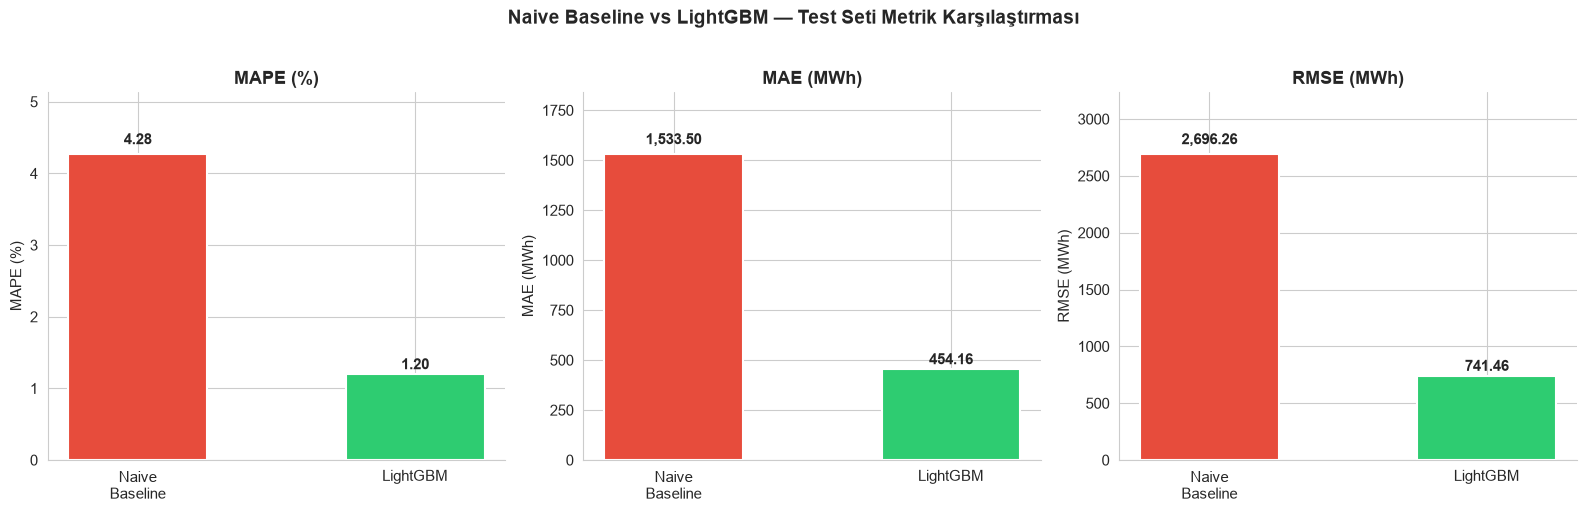

Grafik kaydedildi: outputs/figures/metric_comparison.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metric_names = ['MAPE (%)', 'MAE (MWh)', 'RMSE (MWh)']
naive_vals   = [metrics_naive['MAPE'], metrics_naive['MAE'], metrics_naive['RMSE']]
lgbm_vals    = [metrics_lgbm['MAPE'],  metrics_lgbm['MAE'],  metrics_lgbm['RMSE']]

colors = ['#e74c3c', '#2ecc71']

for ax, name, nv, lv in zip(axes, metric_names, naive_vals, lgbm_vals):
    bars = ax.bar(['Naive\nBaseline', 'LightGBM'], [nv, lv], color=colors, width=0.5, edgecolor='white', linewidth=1.5)
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_ylabel(name)
    for bar, val in zip(bars, [nv, lv]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                f'{val:,.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_ylim(0, max(nv, lv) * 1.20)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Naive Baseline vs LightGBM — Test Seti Metrik Karşılaştırması', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik kaydedildi: outputs/figures/metric_comparison.png')

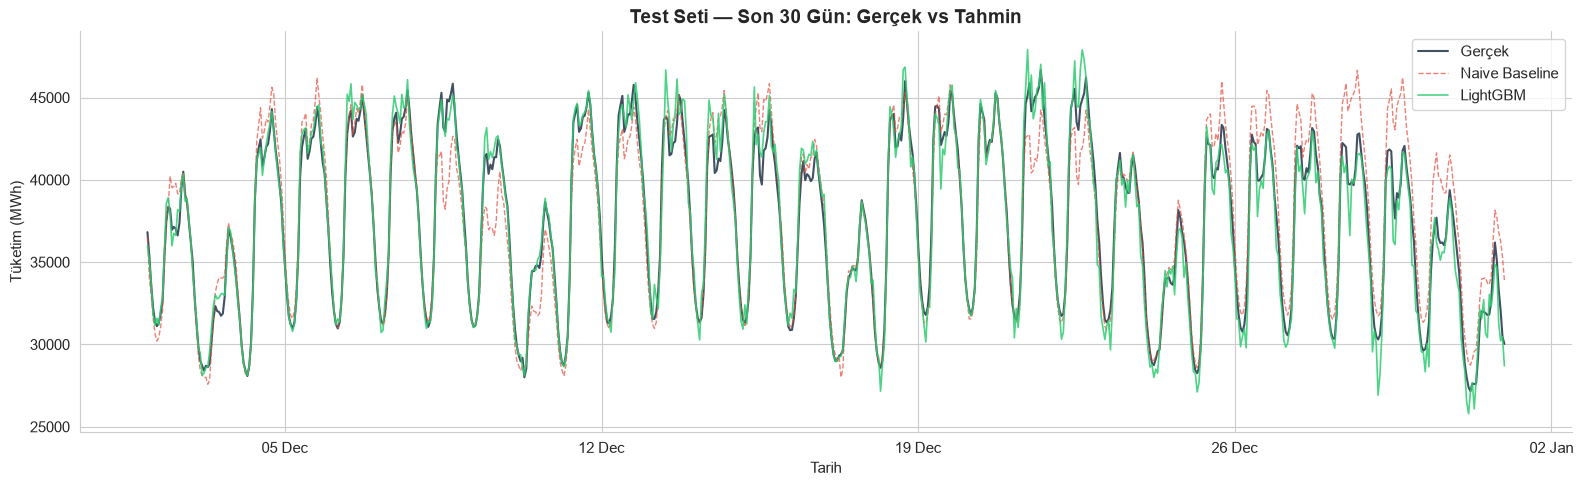

Grafik kaydedildi: outputs/figures/timeseries_last30days.png


In [10]:
# Son 30 gün
last_30d = test_df['datetime'].max() - pd.Timedelta(days=30)
mask_30  = test_df['datetime'] >= last_30d

dates_30  = test_df.loc[mask_30, 'datetime']
actual_30 = y_test.loc[mask_30]
naive_30  = test_df.loc[mask_30, 'lag_168']
lgbm_30   = lgbm_pred[mask_30.values]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(dates_30, actual_30, label='Gerçek', color='#2c3e50', linewidth=1.5, alpha=0.9)
ax.plot(dates_30, naive_30,  label='Naive Baseline', color='#e74c3c', linewidth=1, linestyle='--', alpha=0.7)
ax.plot(dates_30, lgbm_30,   label='LightGBM', color='#2ecc71', linewidth=1.2, alpha=0.85)

ax.set_title('Test Seti — Son 30 Gün: Gerçek vs Tahmin', fontsize=14, fontweight='bold')
ax.set_xlabel('Tarih')
ax.set_ylabel('Tüketim (MWh)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.legend(loc='upper right', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/figures/timeseries_last30days.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik kaydedildi: outputs/figures/timeseries_last30days.png')

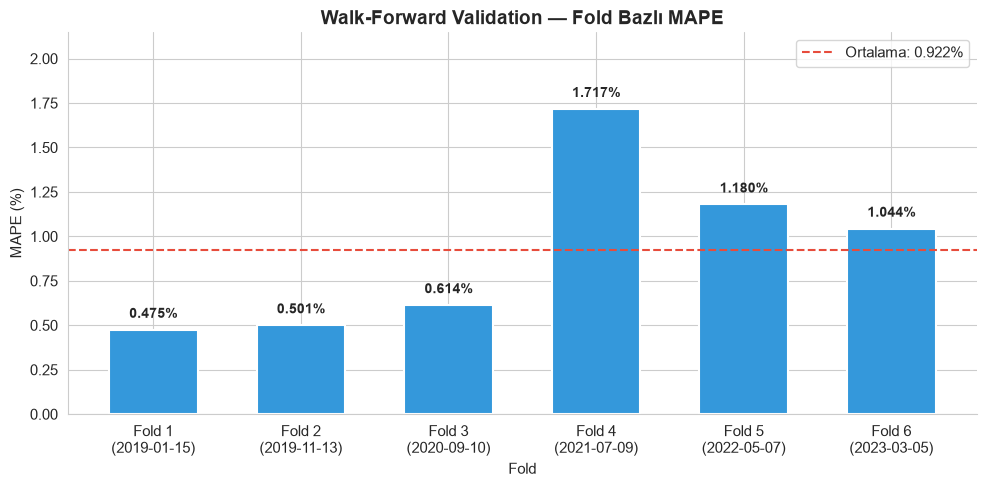

Grafik kaydedildi: outputs/figures/wfv_mape_folds.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

fold_labels = [f'Fold {r["Fold"]}\n({r["test_start"]})' for _, r in wfv_df.iterrows()]
bars = ax.bar(fold_labels, wfv_df['MAPE'], color='#3498db', edgecolor='white', linewidth=1.5, width=0.6)

for bar, val in zip(bars, wfv_df['MAPE']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{val:.3f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

mean_mape = wfv_df['MAPE'].mean()
ax.axhline(mean_mape, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Ortalama: {mean_mape:.3f}%')
ax.set_title('Walk-Forward Validation — Fold Bazlı MAPE', fontsize=14, fontweight='bold')
ax.set_ylabel('MAPE (%)')
ax.set_xlabel('Fold')
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, wfv_df['MAPE'].max() * 1.25)
plt.tight_layout()
plt.savefig('../outputs/figures/wfv_mape_folds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik kaydedildi: outputs/figures/wfv_mape_folds.png')

## 8. Model Kaydetme

Final LightGBM modeli `models/lgbm_model.pkl` dosyasına `pickle` ile kaydediliyor. Bu model:
- SHAP analizi (notebook 04) için
- Streamlit dashboard (app/dashboard.py) için
- Üretim ortamında tahmin için

kullanılabilir.

In [12]:
model_path = '../models/lgbm_model.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(model, f)

# Feature listesini de kaydet (inference için gerekli)
meta_path = '../models/model_meta.pkl'
meta = {
    'features': FEATURES,
    'target': TARGET,
    'best_iteration': model.best_iteration_,
    'test_metrics': metrics_lgbm,
    'naive_metrics': metrics_naive,
    'wfv_mean_mape': wfv_df['MAPE'].mean(),
    'wfv_std_mape': wfv_df['MAPE'].std()
}
with open(meta_path, 'wb') as f:
    pickle.dump(meta, f)

print(f'Model kaydedildi : {model_path}')
print(f'Meta kaydedildi  : {meta_path}')

import os
size_kb = os.path.getsize(model_path) / 1024
print(f'Model boyutu     : {size_kb:.1f} KB')

Model kaydedildi : ../models/lgbm_model.pkl
Meta kaydedildi  : ../models/model_meta.pkl
Model boyutu     : 3630.1 KB


## 9. Özet

Model eğitim ve değerlendirme aşaması tamamlandı. Aşağıda sonuçların özeti yer almaktadır:

In [13]:
print('=' * 55)
print('         MODEL SONUCLARI OZETI')
print('=' * 55)
print(f"{'Model':<25} {'MAPE':>10} {'MAE':>12} {'RMSE':>12}")
print('-' * 55)
print(f"{'Naive Baseline':<25} {metrics_naive['MAPE']:>9.3f}% {metrics_naive['MAE']:>11,.0f} {metrics_naive['RMSE']:>11,.0f}")
print(f"{'LightGBM':<25} {metrics_lgbm['MAPE']:>9.3f}% {metrics_lgbm['MAE']:>11,.0f} {metrics_lgbm['RMSE']:>11,.0f}")
print('-' * 55)
wfv_mape_mean = wfv_df['MAPE'].mean()
wfv_mape_std  = wfv_df['MAPE'].std()
print(f"{'WFV Ortalama':<25} {wfv_mape_mean:>9.3f}%  +/- {wfv_mape_std:.3f}%")
print('=' * 55)

improvement = (metrics_naive['MAPE'] - metrics_lgbm['MAPE']) / metrics_naive['MAPE'] * 100
print(f'\nLightGBM, Naive Baseline gore MAPE yi %{improvement:.1f} iyilestirdi.')
print(f'En iyi iterasyon: {model.best_iteration_}')
print('\nKaydedilen dosyalar:')
print('  - models/lgbm_model.pkl')
print('  - models/model_meta.pkl')
print('  - outputs/figures/metric_comparison.png')
print('  - outputs/figures/timeseries_last30days.png')
print('  - outputs/figures/wfv_mape_folds.png')


         MODEL SONUCLARI OZETI
Model                           MAPE          MAE         RMSE
-------------------------------------------------------
Naive Baseline                4.277%       1,533       2,696
LightGBM                      1.198%         454         741
-------------------------------------------------------
WFV Ortalama                  0.922%  +/- 0.487%

LightGBM, Naive Baseline gore MAPE yi %72.0 iyilestirdi.
En iyi iterasyon: 687

Kaydedilen dosyalar:
  - models/lgbm_model.pkl
  - models/model_meta.pkl
  - outputs/figures/metric_comparison.png
  - outputs/figures/timeseries_last30days.png
  - outputs/figures/wfv_mape_folds.png
